In [1]:
#Creating Lambda and LMP Dataframes
import pandas as pd
import sqlite3

# Path to the SQLite database file
database_path = 'E:/Plsworkbro.db'

# Connect to the SQLite database
conn = sqlite3.connect(database_path)

# Table names
tables = ['DAM_System_Lambda', 'DAM_LMP_Combined']

# Initialize a dictionary to hold the dataframes
dataframes = {}

# Load each table into a dataframe and store it in the dictionary
for table in tables:
    query = f"SELECT * FROM {table}"
    dataframes[table] = pd.read_sql_query(query, conn)

# Close the connection to the database
conn.close()

# The dataframes are now loaded and can be accessed as follows:
# dataframes['CompiledCSVData'], dataframes['DAM_LMP_Combined'], dataframes['DAM_Shadow_Combined']

# To verify, you can print out the first few rows of each dataframe
for table, df in dataframes.items():
    print(f"First few rows of the '{table}' table:")
    print(df.head())


C:\Users\ggall\AppData\Local\Temp\ipykernel_28740\4100445746.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


First few rows of the 'DAM_System_Lambda' table:
  DeliveryDate  HourEnding  SystemLambda DSTFlag
0   2023-05-30           1       13.3238       N
1   2023-05-30           2       11.7500       N
2   2023-05-30           3       11.4561       N
3   2023-05-30           4       11.5906       N
4   2023-05-30           5       12.7662       N
First few rows of the 'DAM_LMP_Combined' table:
  DeliveryDate HourEnding SettlementPoint  SettlementPointPrice DSTFlag
0   01/02/2017      01:00            AEEC                 17.32       N
1   01/02/2017      01:00     AMISTAD_ALL                 17.71       N
2   01/02/2017      01:00    AMOCOOIL_CC1                 17.52       N
3   01/02/2017      01:00    AMOCOOIL_CC2                 17.52       N
4   01/02/2017      01:00      AMOCO_PUN1                 17.52       N


In [2]:
#Fixed Date and HE columns
import pandas as pd

# Assuming 'dataframes' is a dictionary containing your dataframes
# dataframes = {'DAM_LMP_Combined': dataframe1, 'DAM_Shadow_Combined': dataframe2, 'CompiledCSVData': dataframe3}

# Function to fix the date and hour formats within the dataframe
def fix_date_hour_formats(df, date_column='DeliveryDate', hour_column='HourEnding'):
    # Fix the DeliveryDate format
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce').dt.strftime('%Y-%m-%d')
    
    # Fix the HourEnding format assuming it's in 'HH:MM' format and we just need the 'HH' part
    if df[hour_column].dtype == 'O':  # If the type is 'object' (typically for strings in pandas)
        df[hour_column] = df[hour_column].str.extract(r'(\d+):').astype(float)
    else:  # If it's not an object, it might be numeric or mixed types
        df[hour_column] = df[hour_column].apply(lambda x: str(x).split(':')[0]).astype(float)
    
    # Return the modified DataFrame
    return df

# Apply the function to each DataFrame
for table_name in dataframes.keys():
    dataframes[table_name] = fix_date_hour_formats(dataframes[table_name])

# Verify the changes by printing the first few rows of each DataFrame
for table_name in dataframes.keys():
    print(f"Fixed formats for table {table_name}:")
    print(dataframes[table_name].head())


Fixed formats for table DAM_System_Lambda:
  DeliveryDate  HourEnding  SystemLambda DSTFlag
0   2023-05-30         1.0       13.3238       N
1   2023-05-30         2.0       11.7500       N
2   2023-05-30         3.0       11.4561       N
3   2023-05-30         4.0       11.5906       N
4   2023-05-30         5.0       12.7662       N
Fixed formats for table DAM_LMP_Combined:
  DeliveryDate  HourEnding SettlementPoint  SettlementPointPrice DSTFlag
0   2017-01-02         1.0            AEEC                 17.32       N
1   2017-01-02         1.0     AMISTAD_ALL                 17.71       N
2   2017-01-02         1.0    AMOCOOIL_CC1                 17.52       N
3   2017-01-02         1.0    AMOCOOIL_CC2                 17.52       N
4   2017-01-02         1.0      AMOCO_PUN1                 17.52       N


In [3]:
# Merge the DataFrames on 'DeliveryDate' and 'HourEnding' columns (DAM LMP + System Lambda) and Price Difference
merged_df = pd.merge(dataframes['DAM_LMP_Combined'],
                       dataframes['DAM_System_Lambda'][['DeliveryDate', 'HourEnding', 'SystemLambda']],
                       on=['DeliveryDate', 'HourEnding'],
                       how='left')

# Add a new column 'Price_Difference' by subtracting 'SettlementPointPrice' from 'SystemLambda'
merged_df['Price_Difference'] = merged_df['SettlementPointPrice'] - merged_df['SystemLambda']

# Display the first few rows of the merged dataframe to verify
merged_df.head()

,DeliveryDate,HourEnding,SettlementPoint,SettlementPointPrice,DSTFlag,SystemLambda,Price_Difference
0,2017-01-02,1.0,AEEC,17.32,N,17.5436,-0.2236
1,2017-01-02,1.0,AMISTAD_ALL,17.71,N,17.5436,0.1664
2,2017-01-02,1.0,AMOCOOIL_CC1,17.52,N,17.5436,-0.0236
3,2017-01-02,1.0,AMOCOOIL_CC2,17.52,N,17.5436,-0.0236
4,2017-01-02,1.0,AMOCO_PUN1,17.52,N,17.5436,-0.0236


In [14]:
#Making the Constraints Dataframe
import pandas as pd
import sqlite3

# Define the database path and connect to the SQLite database
database_path = 'E:/Plsworkbro.db'
conn = sqlite3.connect(database_path)

# Load the 'DAM_Shadow_Combined' table into a DataFrame
query = "SELECT * FROM DAM_Shadow_Combined"
df_shadow_combined = pd.read_sql_query(query, conn)

# Close the connection to the database
conn.close()

# Fix the date and hour formats
df_shadow_combined = fix_date_hour_formats(df_shadow_combined)

# Combine 'ConstraintName' and 'ContingencyName' to create a unique identifier for each combination
df_shadow_combined['Constraint_Contingency'] = df_shadow_combined['ConstraintName'] + '_' + df_shadow_combined['ContingencyName']

# Pivot the table with these unique identifiers as columns, 'DeliveryDate' and 'HourEnding' as the index, 
# and 'ShadowPrice' as the values
pivot_df = df_shadow_combined.pivot_table(
    index=['DeliveryDate', 'HourEnding'],
    columns='Constraint_Contingency',
    values='ShadowPrice',
    fill_value=0
)

# Now you have a pivot table 'pivot_df' with each Constraint_Contingency as a column
# and each row representing an hour for a specific date, filled with zeros where there are no records


In [15]:
#Number of Records and Columns in Both Dataframes and Date Range
# Counting the number of rows in the merged dataframe
row_count = pivot_df.shape[0]
print(f"Constraints Rows: {row_count}")
row_count2 = merged_df.shape[0]
print(f"LMPs Rows: {row_count}")

column_count = pivot_df.shape[1]
print(f"Constraints Columns: {column_count}")
column_count2 = merged_df.shape[1]
print(f"LMPs Columns: {column_count2}")

min_date = pivot_df.index.get_level_values('DeliveryDate').min()
max_date = pivot_df.index.get_level_values('DeliveryDate').max()
print(f"Constraints Date Range: {min_date} to {max_date}")
date_range2 = merged_df['DeliveryDate'].agg(['min', 'max'])
print(f"LMPs Date Range: {date_range2['min']} to {date_range2['max']}")

max_value = merged_df['Price_Difference'].max()
min_value = merged_df['Price_Difference'].min()
mean_value = merged_df['Price_Difference'].mean()
stdev_value = merged_df['Price_Difference'].std()

gmax_value = merged_df['SystemLambda'].max()
gmin_value = merged_df['SystemLambda'].min()
gmean_value = merged_df['SystemLambda'].mean()
gstdev_value = merged_df['SystemLambda'].std()

print(f"Mean..PriceDifference: {mean_value:.2f} and Lambda: {gmean_value:.2f}")
print(f"Min..PriceDifference: {min_value:.2f} and Lambda: {gmin_value:.2f}")
print(f"Max..PriceDifference: {max_value:.2f} and Lambda: {gmax_value:.2f}")
print(f"Stdev..PriceDifference: {stdev_value:.2f} and Lambda: {gstdev_value:.2f}")

Constraints Rows: 61335
LMPs Rows: 61335
Constraints Columns: 13455
LMPs Columns: 7
Constraints Date Range: 2017-01-02 to 2024-01-01
LMPs Date Range: 2017-01-02 to 2024-01-10
Mean..PriceDifference: 2.12 and Lambda: 54.70
Min..PriceDifference: -8003.77 and Lambda: -94.18
Max..PriceDifference: 14576.27 and Lambda: 8982.97
Stdev..PriceDifference: 25.75 and Lambda: 359.43


In [6]:
# Sum up the total of the shadow price across all constraints, print as an excel file, and print out a chart of this across the entire series
import pandas as pd

# Assuming pivot_df is your pivot table DataFrame from previous steps

# Drop the 'Total' column if it already exists to avoid summing it again
pivot_df = pivot_df.drop(columns='Total', errors='ignore')

# Sum up the total for every single hour across all constraints and contingencies
pivot_df['Total'] = pivot_df.sum(axis=1)

# Reset the index which will move 'DeliveryDate' and 'HourEnding' from the index back to columns
pivot_df_reset = pivot_df.reset_index()

# Create a new DataFrame with just the date, hour, and total
total_hourly_df = pivot_df_reset[['DeliveryDate', 'HourEnding', 'Total']]

# Exclude the 'Total' column when calculating statistics for the original columns
stats_columns = pivot_df.drop(columns=['Total'], errors='ignore')
column_means = stats_columns.mean()
column_stds = stats_columns.std()

# Create a new DataFrame with the mean and standard deviation
stats_df = pd.DataFrame({'Mean': column_means, 'Standard Deviation': column_stds})

# Define the path for the new CSV files
output_file_path_total = 'E:/total_hourly_data.csv'
output_file_path_stats = 'E:/column_statistics.csv'

# Export the DataFrames to CSV
total_hourly_df.to_csv(output_file_path_total, index=False)
stats_df.to_csv(output_file_path_stats, index=True)

print(f'Saved the summed hourly data to {output_file_path_total}')
print(f'Saved the statistics data to {output_file_path_stats}')

Saved the summed hourly data to E:/total_hourly_data.csv
Saved the statistics data to E:/column_statistics.csv


In [16]:
# Standardizing the Delivery Date and Hour Ending form for Regression and Putting in 0s for NaaN values
import pandas as pd

# Assuming merged_df and pivot_df are predefined DataFrames.

# Function to standardize 'DeliveryDate' and 'HourEnding'
def standardize_date_hour(df):
    # Standardize 'DeliveryDate' format
    df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate']).dt.date
    
    # Standardize 'HourEnding' format
    df['HourEnding'] = df['HourEnding'].astype(int)
    
    return df

# Clean 'merged_df'
final_table = merged_df.drop(columns=['SettlementPointPrice', 'DSTFlag', 'SystemLambda'])

# Standardize 'DeliveryDate' and 'HourEnding' for 'cleaned_merged_df'
final_table = standardize_date_hour(final_table)

# Display the first few rows of the cleaned 'merged_df'
print("Final_Table DataFrame:")
print(final_table.head())

# Clean 'pivot_df': Convert all numeric values to floats and replace NaNs with zeros
final_constraints = pivot_df.astype(float).fillna(0)

# Reset the index for 'cleaned_pivot_df' to standardize 'DeliveryDate' and 'HourEnding'
final_constraints.reset_index(inplace=True)
final_constraints = standardize_date_hour(final_constraints)

# Display the first few rows of the cleaned 'pivot_df'
print("\nFinal_Constraints DataFrame:")
print(final_constraints.head())


Final_Table DataFrame:
  DeliveryDate  HourEnding SettlementPoint  Price_Difference
0   2017-01-02           1            AEEC           -0.2236
1   2017-01-02           1     AMISTAD_ALL            0.1664
2   2017-01-02           1    AMOCOOIL_CC1           -0.0236
3   2017-01-02           1    AMOCOOIL_CC2           -0.0236
4   2017-01-02           1      AMOCO_PUN1           -0.0236

Final_Constraints DataFrame:
Constraint_Contingency DeliveryDate  HourEnding   100027_D_1_  BASE CASE  \
0                        2017-01-02           1                      0.0   
1                        2017-01-02           2                      0.0   
2                        2017-01-02           3                      0.0   
3                        2017-01-02           4                      0.0   
4                        2017-01-02           5                      0.0   

Constraint_Contingency   100027_D_1_ DBUCBWN5   100027_D_1_ DBWNKLN5  \
0                                         0.0       

In [17]:
#Lasso regression with alpha optimization
#regress_settlement_point(settlement_point, final_constraints, final_table, alpha='optimize', train_min=0.7, test_max=0.3)
import pandas as pd
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

def regress_settlement_point(settlement_point, final_constraints, final_table, alpha='optimize', train_min=0.7, test_max=0.3):
    output_dir = r"E:\Lasso Results\\"  # Adjusted for Windows path

    if train_min + test_max > 1.0:
        raise ValueError("The sum of train_min and test_max should be less than or equal to 1.0")

    # Filter and merge data
    settlement_data = final_table[final_table['SettlementPoint'] == settlement_point]
    merged_data = pd.merge(final_constraints, settlement_data, on=['DeliveryDate', 'HourEnding'], how='inner')
    features = merged_data.drop(columns=['DeliveryDate', 'HourEnding', 'SettlementPoint', 'Price_Difference'])
    target = merged_data['Price_Difference']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(features, target, train_size=train_min, test_size=test_max, random_state=42)

    # Determine whether to optimize alpha
    if alpha == 'optimize':
        lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_train, y_train)
        optimized_alpha = lasso_cv.alpha_
        lasso = Lasso(alpha=optimized_alpha)
        print(f"Optimized alpha: {optimized_alpha}")
    else:
        lasso = Lasso(alpha=alpha)

    # Fit Lasso model
    lasso.fit(X_train, y_train)

    # Predict and calculate MSE
    y_pred = lasso.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)

    # Select features with non-zero coefficients
    selected_features = features.columns[(lasso.coef_ != 0)].tolist()

    results_df = pd.DataFrame()

    if selected_features:
        # OLS Regression on Selected Features for detailed stats
        X_selected = features[selected_features]
        X_selected_with_const = sm.add_constant(X_selected)
        ols_model = sm.OLS(target, X_selected_with_const).fit()

        # Extracting coefficients, standard errors, and p-values
        results_df = pd.DataFrame({
            'Constraint': selected_features,
            'Coefficient': ols_model.params.values[1:],  # Skipping the constant
            'Standard Error': ols_model.bse.values[1:],  # Skipping the constant for standard errors
            'P-Value': ols_model.pvalues.values[1:]  # Skipping the constant for p-values
        })

        # Calculate z-scores for coefficients
        results_df['Z-Score'] = results_df['Coefficient'] / results_df['Standard Error']

        # Plotting and saving plot to file, focusing on z-scores
        plt.figure(figsize=(10, 6))
        plt.scatter(results_df['Z-Score'], results_df['Coefficient'], alpha=0.5)

        # Limit the x-axis to the range of z-scores to focus on the bulk of the data
        plt.xlim(results_df['Z-Score'].min() - 1, results_df['Z-Score'].max() + 1)

        plt.xlabel('Z-Score')
        plt.ylabel('Coefficient Value')
        plt.title(f'Coefficient Values vs. Z-Scores for {settlement_point}')
        plt.grid(True)
        plot_filename = f"{output_dir}{settlement_point}_coefficients_vs_zscores.png"
        plt.savefig(plot_filename)
        plt.close()

        # Saving regression results to CSV
        csv_filename = f"{output_dir}{settlement_point}_regression_results.csv"
        results_df.to_csv(csv_filename, index=False)

    print(f"Mean Squared Error for settlement point {settlement_point}: {mse}")
    print(f"Plot saved to: {plot_filename}")
    print(f"CSV saved to: {csv_filename}")

    # Return the fitted Lasso model, MSE, selected features, OLS model, and results dataframe
    return lasso, mse, selected_features, ols_model if 'ols_model' in locals() else None, results_df


In [19]:
#Iterating through entire SettlementPoints with 70/30 Split
import pandas as pd
import os

# Initialize a DataFrame to store the MSE and alpha values
mse_alpha_df = pd.DataFrame(columns=['SettlementPoint', 'MSE', 'OptimizedAlpha'])

# Set the output directory
output_dir = r"E:\Lasso Results\\"

# Assuming 'SettlementPoints' is a list of all unique settlement points from your DataFrame.
SettlementPoints = merged_df['SettlementPoint'].unique().tolist()

# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through each settlement point and perform regression
for point in SettlementPoints:
    try:
        # Unpack the results from your regression function call
        lasso, mse, selected_features, ols_model, results_df, optimized_alpha = regress_settlement_point(
            settlement_point=point,
            final_constraints=final_constraints,
            final_table=final_table,
            alpha='optimize',
            train_min=0.7,
            test_max=0.3
        )
        
        # Append the MSE and alpha values to the DataFrame
        mse_alpha_df = mse_alpha_df.append({
            'SettlementPoint': point,
            'MSE': mse,
            'OptimizedAlpha': optimized_alpha
        }, ignore_index=True)

    except Exception as e:
        # If an error occurs, print it and continue to the next settlement point
        print(f"Error occurred for {point}: {e}")
        continue

# Define the file name based on the train/test split
split_ratio_filename = f"{int(0.7 * 100)}_{int(0.3 * 100)}_split_MSE_and_Alpha.csv"
mse_alpha_csv_path = os.path.join(output_dir, split_ratio_filename)

# Save the MSE and alpha values DataFrame to a CSV file
mse_alpha_df.to_csv(mse_alpha_csv_path, index=False)

print(f"MSE and optimized alpha values saved to {mse_alpha_csv_path}")

Error occurred for AEEC: Unable to allocate 3.45 GiB for an array with shape (34374, 13455) and data type float64
Error occurred for AMISTAD_ALL: Unable to allocate 3.45 GiB for an array with shape (34374, 13455) and data type float64
Error occurred for AMOCOOIL_CC1: Unable to allocate 3.45 GiB for an array with shape (34374, 13455) and data type float64


KeyboardInterrupt: 

In [20]:
BRP_PBL1_RN = regress_settlement_point(
    settlement_point='BRP_PBL1_RN',  # Replace with the actual SettlementPoint you are analyzing
    final_constraints=final_constraints,
    final_table=final_table,
    alpha='optimize',  # Adjust this based on your regularization needs
    train_min=0.7,  # Proportion of data to use for training
    test_max=0.3,  # Proportion of data to use for testing
)

MemoryError: Unable to allocate 1.35 GiB for an array with shape (13455, 13455) and data type float64

C:\Users\ggall\AppData\Local\Temp\ipykernel_26112\435268452.py:17: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  plt.plot(final_constraints['DeliveryDate'] + pd.to_timedelta(final_constraints['HourEnding']-1, unit='h'), final_constraints[max_avg_column], label=max_avg_column)


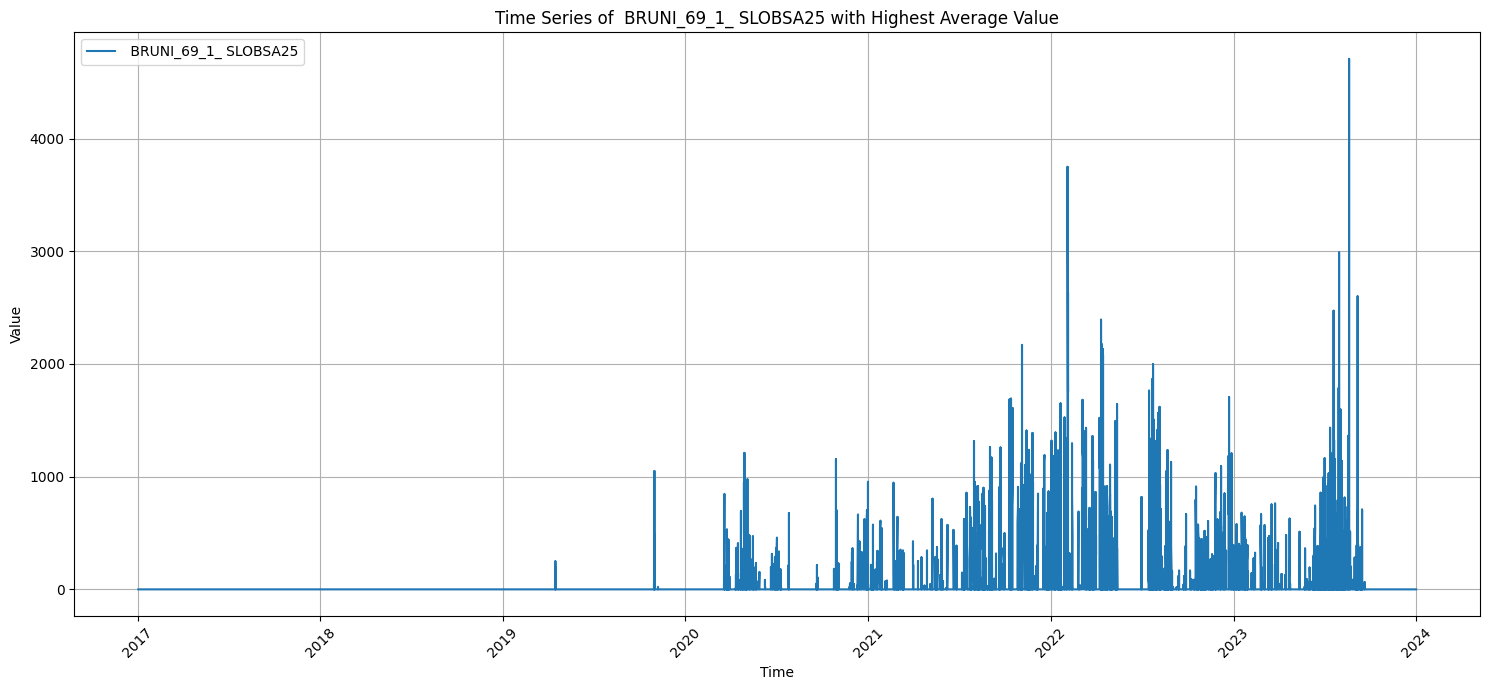

In [30]:
#Plotting the highest average shadow price of a constraint and its time series
import pandas as pd
import matplotlib.pyplot as plt

# Please ensure your final_constraints DataFrame is loaded correctly and resembles the structure of the placeholder DataFrame.
# For example:
# final_constraints = pd.read_csv('path_to_your_csv.csv')

# Now, using your actual `final_constraints` DataFrame, we will find the column with the highest average value.

# Exclude 'DeliveryDate' and 'HourEnding' from the mean calculation
average_values = final_constraints.drop(['DeliveryDate', 'HourEnding'], axis=1).mean()
max_avg_column = average_values.idxmax()

# Now, create a graph of the column with the highest average value across the entire time series
plt.figure(figsize=(15, 7))
plt.plot(final_constraints['DeliveryDate'] + pd.to_timedelta(final_constraints['HourEnding']-1, unit='h'), final_constraints[max_avg_column], label=max_avg_column)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f"Time Series of {max_avg_column} with Highest Average Value")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability if needed
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()


In [65]:
# plot_prices() Plotting DA LMPs function so I can see the SettlementPoint Price of Nodes and Print an image
def plot_prices(merged_df, settlement_points, start_date, end_date, system_lambda_col='SystemLambda', output_dir="E:\\Lasso Results\\DA LMP Chart Series\\", window=24):
    # Make a copy to avoid SettingWithCopyWarning when sorting
    plot_data = merged_df.copy()

    # Convert 'DeliveryDate' and 'HourEnding' to datetime for plotting
    plot_data['DateTime'] = pd.to_datetime(plot_data['DeliveryDate']) + pd.to_timedelta(plot_data['HourEnding'] - 1, unit='h')
    
    # Filter the DataFrame for the specified date range
    plot_data = plot_data[(plot_data['DateTime'] >= pd.to_datetime(start_date)) & (plot_data['DateTime'] <= pd.to_datetime(end_date))]

    # Sort the data by DateTime
    plot_data.sort_values('DateTime', inplace=True)

    # Create the figure
    fig, ax = plt.subplots(figsize=(15, 7))

    # System Lambda should only be plotted once, so we pick it from the first specified settlement point
    # Apply a moving average to the System Lambda series to smooth out the line
    system_lambda_data = plot_data.loc[plot_data['SettlementPoint'] == settlement_points[0], [system_lambda_col, 'DateTime']]
    system_lambda_smoothed = system_lambda_data[system_lambda_col].rolling(window=window, min_periods=1).mean()
    ax.plot(system_lambda_data['DateTime'], system_lambda_smoothed, label='System Lambda (Smoothed)', color='tab:green')

    # Plot SettlementPointPrice for each specified settlement point, smoothed with a rolling window
    for sp in settlement_points:
        subset = plot_data[plot_data['SettlementPoint'] == sp]
        sp_price_smoothed = subset['SettlementPointPrice'].rolling(window=window, min_periods=1).mean()
        ax.plot(subset['DateTime'], sp_price_smoothed, label=f'{sp} Price (Smoothed)')

    # Labeling the plot
    ax.set_xlabel('Date and Time')
    ax.set_ylabel('Price (Smoothed)')
    ax.set_title('Settlement Point Prices and System Lambda')
    ax.legend()
    ax.grid(True)

    # Save the figure
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    filename = f"{'_'.join(settlement_points)}_{start_date}_to_{end_date}.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath)
    plt.close(fig)

    return filepath

# Example usage:
settle = ['BRP_PBL1_RN']  # Add more settlement point names to the list if needed
start = '2018-01-01'
end = '2023-12-31'
# Assume merged_df is already defined and loaded with data
filepath = plot_prices(merged_df, settle, start, end)
print(f"Chart saved to {filepath}")

Chart saved to E:\Lasso Results\DA LMP Chart Series\BRP_PBL1_RN_2018-01-01_to_2023-12-31.png
